# Heart Disease Prediction — F2-Optimised Pipeline
**BorderlineSMOTE | Per-fold F2 Threshold Tuning | Soft-Voting Ensemble | Grid Search HPO**

| Improvement | Why it helps F2 |
|---|---|
| F2-optimal threshold search per fold | F2 β=2 weights recall 4× — threshold <0.5 almost always wins |
| BorderlineSMOTE | Synthesises near-boundary minority samples — better recall |
| `scale_pos_weight` / `is_unbalance` | Native gradient-booster imbalance handling |
| Grid search HPO | Searches XGB & LGBM grids (48 combos) optimising F2 |
| Soft-voting ensemble (top-3 by F2) | Probability averaging reduces variance |


## 1. Imports & Setup

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools, time

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, fbeta_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import BorderlineSMOTE

RANDOM_STATE = 42
N_SPLITS = 5

try:
    import xgboost as xgb; HAS_XGB = True
except ImportError:
    HAS_XGB = False; print('XGBoost not installed')
try:
    import lightgbm as lgb; HAS_LGBM = True
except ImportError:
    HAS_LGBM = False; print('LightGBM not installed')
try:
    import catboost as cb; HAS_CB = True
except ImportError:
    HAS_CB = False; print('CatBoost not installed')

print('All imports done.')


All imports done.


## 2. Column Mapping & Encoding Dictionaries

In [ ]:
COLUMN_MAP = {
    'ID':                                     'id',
    'History of HeartDisease or Attack':      'target',
    'High Blood Pressure':                    'high_bp',
    'Told High Cholesterol':                  'high_chol',
    'Cholesterol Checked':                    'chol_checked',
    'Body Mass Index':                        'bmi',
    'Smoked 100+ Cigarettes':                 'smoker',
    'Diagnosed Stroke':                       'stroke',
    'Diagnosed Diabetes':                     'diabetes',
    'Leisure Physical Activity':              'physical_activity',
    'Heavy Alcohol Consumption':              'heavy_alcohol',
    'Health Care Coverage':                   'healthcare_coverage',
    'Doctor Visit Cost Barrier':              'cost_barrier',
    'General Health':                         'gen_health',
    'Difficulty Walking':                     'diff_walking',
    'Sex':                                    'sex',
    'Education Level':                        'education',
    'Income Level':                           'income',
    'Age':                                    'age',
    'Vegetable or Fruit Intake (1+ per Day)': 'fruit_veg',
}

BINARY_COLS = [
    'high_bp','high_chol','chol_checked','smoker','stroke',
    'diabetes','physical_activity','heavy_alcohol','healthcare_coverage',
    'cost_barrier','diff_walking','fruit_veg',
]

GEN_HEALTH_MAP  = {'Excellent':1,'Good':2,'Fair':3,'Poor':4,'Very Poor':5}
EDUCATION_MAP   = {'Never attended school':1,'Elementary':2,'Some high school':3,
                   'High school graduate':4,'Some college or technical school':5,'College graduate':6}
INCOME_MAP      = {'Less than $10,000':1,'($10,000 to less than $15,000':2,
                   '$15,000 to less than $20,000':3,'$20,000 to less than $25,000':4,
                   '$25,000 to less than $35,000':5,'$35,000 to less than $50,000':6,
                   '$50,000 to less than $75,000':7,'$75,000 or more':8}
print('Maps defined.')


Maps defined.


## 3. Load Data

In [ ]:
TRAIN_PATH = '/kaggle/input/competitions/super-ai-engineer-ss-6-heart-disease-prediction/train.csv'
TEST_PATH  = '/kaggle/input/competitions/super-ai-engineer-ss-6-heart-disease-prediction/test.csv'

df_raw = pd.read_csv(TRAIN_PATH)
df_raw.rename(columns=COLUMN_MAP, inplace=True)
if 'id' in df_raw.columns:
    df_raw.drop(columns=['id'], inplace=True)
print(f'Shape: {df_raw.shape}')
print(f'Target values: {df_raw["target"].unique()}')
print(f'Missing target: {df_raw["target"].isnull().sum()}')


Shape: (223084, 19)
Target values: ['No' nan 'Yes']
Missing target: 1694


## 4. Encoding

Convert all text columns to numeric before imputation:
- **Binary** (`Yes`/`No`) → 1/0
- **Sex** → Male=1, Female=0
- **gen_health** → ordinal 1–5 (1=Excellent, 5=Very Poor)
- **education** → ordinal 1–6, **income** → ordinal 1–8
- **target** NaN rows dropped (cannot impute labels)


In [ ]:
def encode_data(df, is_train=True):
    df = df.copy()
    if is_train and 'target' in df.columns:
        before = len(df)
        df['target'] = df['target'].map({'Yes':1,'No':0})
        df = df.dropna(subset=['target'])
        df['target'] = df['target'].astype(int)
        print(f'Target encoded. Dropped {before-len(df)} rows with missing target.')
    for col in BINARY_COLS:
        if col in df.columns:
            df[col] = df[col].map({'Yes':1,'No':0})
    if 'sex' in df.columns:
        df['sex'] = df['sex'].map({'Male':1,'Female':0})
    if 'gen_health' in df.columns:
        df['gen_health'] = df['gen_health'].map(GEN_HEALTH_MAP)
    if 'education' in df.columns:
        df['education'] = df['education'].map(EDUCATION_MAP)
    if 'income' in df.columns:
        df['income'] = df['income'].map(INCOME_MAP)
    print(f'Encoding complete. Shape: {df.shape}')
    return df

df_encoded = encode_data(df_raw, is_train=True)
print(f'\nTarget distribution:')
print(df_encoded['target'].value_counts())
ratio = df_encoded['target'].value_counts()[0] / df_encoded['target'].value_counts()[1]
print(f'Imbalance ratio: {ratio:.2f} : 1')
df_encoded.head()


Target encoded. Dropped 1694 rows with missing target.
Encoding complete. Shape: (221390, 19)

Target distribution:
target
0    203322
1     18068
Name: count, dtype: int64
Imbalance ratio: 11.25 : 1


,target,high_bp,high_chol,chol_checked,bmi,smoker,stroke,diabetes,physical_activity,heavy_alcohol,healthcare_coverage,cost_barrier,gen_health,diff_walking,sex,education,income,age,fruit_veg
0,0,1,1.0,1,40.68,1.0,0,0.0,0,0,1,0.0,5.0,1.0,0,4,3,64,1
1,0,0,0.0,0,24.36,1.0,0,0.0,1,0,0,1.0,3.0,0.0,0,6,1,50,0
2,0,1,1.0,1,27.33,0.0,0,0.0,0,0,1,1.0,5.0,1.0,0,4,8,61,1
3,0,1,0.0,1,27.01,0.0,0,0.0,1,0,1,0.0,2.0,0.0,0,3,6,74,1
5,0,1,1.0,1,25.11,1.0,0,0.0,1,0,1,0.0,2.0,0.0,1,6,8,67,1


## 5. EDA

In [ ]:
print('=== Missing Values after encoding ===')
missing = df_encoded.isnull().sum()
miss_df = pd.DataFrame({'count':missing,'pct%':(missing/len(df_encoded)*100).round(2)})
print(miss_df[miss_df['count']>0])
print('\n=== Age & BMI Statistics ===')
print(df_encoded[['age','bmi']].describe().T)


=== Missing Values after encoding ===
              count   pct%
high_chol     32043  14.47
bmi           11725   5.30
smoker            1   0.00
diabetes          3   0.00
cost_barrier      1   0.00
gen_health        1   0.00
diff_walking      3   0.00

=== Age & BMI Statistics ===
        count       mean        std    min    25%    50%    75%     max
age  221390.0  54.660215  17.773171  18.00  42.00  56.00  67.00  100.00
bmi  209665.0  28.181723   6.686984  11.21  23.87  27.06  31.08   98.63


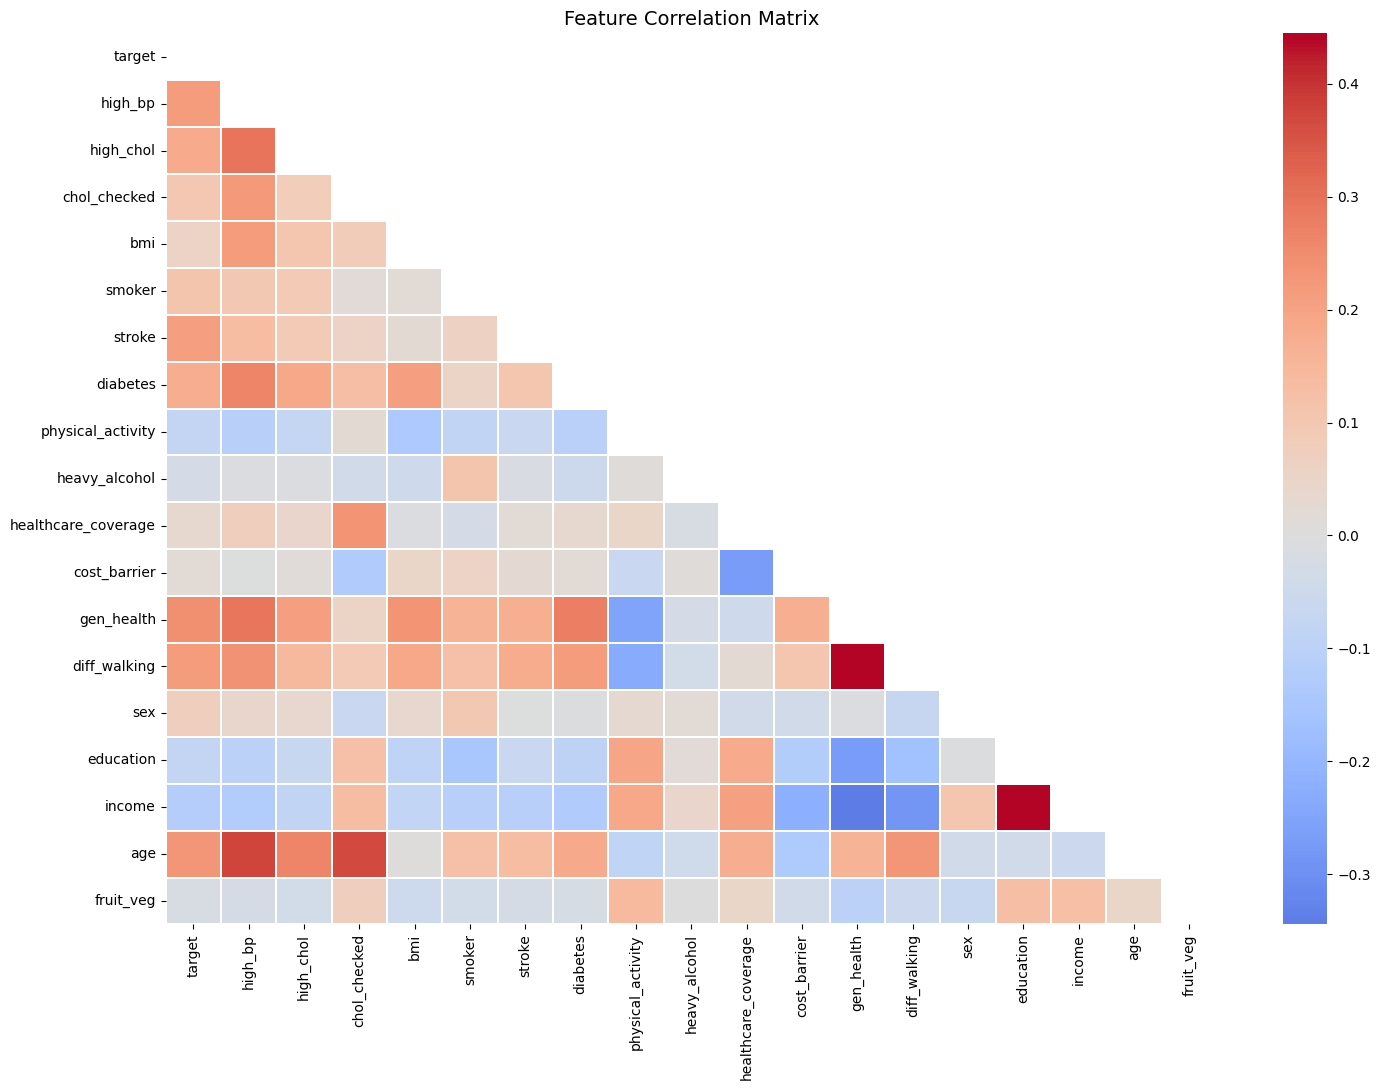

In [ ]:
plt.figure(figsize=(15,11))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,cmap='coolwarm',center=0,annot=False,linewidths=0.3)
plt.title('Feature Correlation Matrix',fontsize=14)
plt.tight_layout(); plt.show()


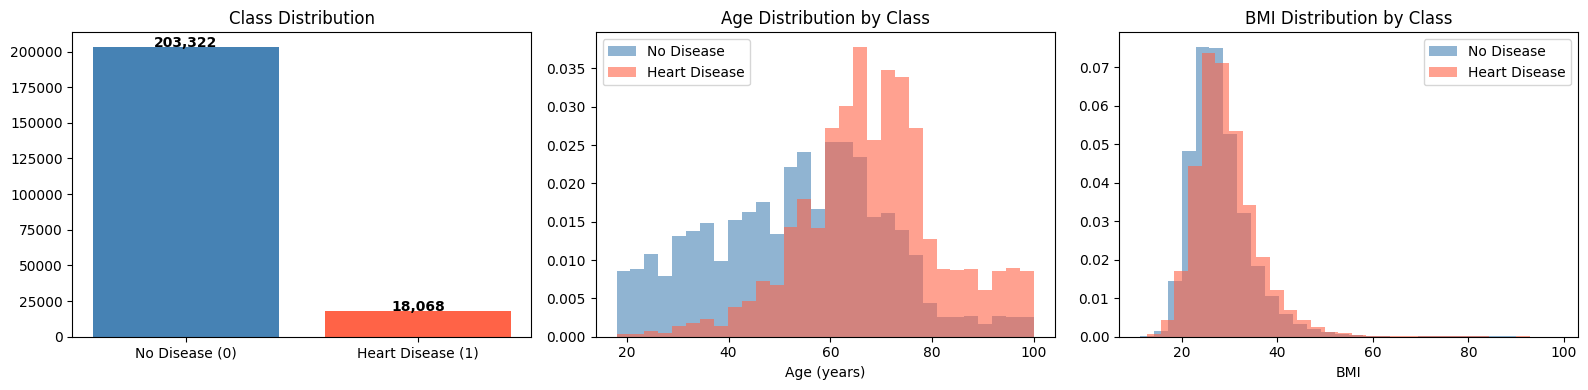

In [ ]:
fig,axes = plt.subplots(1,3,figsize=(16,4))
counts = df_encoded['target'].value_counts()
axes[0].bar(['No Disease (0)','Heart Disease (1)'],counts.values,color=['steelblue','tomato'])
axes[0].set_title('Class Distribution')
for i,v in enumerate(counts.values): axes[0].text(i,v+200,f'{v:,}',ha='center',fontweight='bold')
for label,color,name in [(0,'steelblue','No Disease'),(1,'tomato','Heart Disease')]:
    axes[1].hist(df_encoded[df_encoded['target']==label]['age'],alpha=0.6,bins=30,color=color,label=name,density=True)
axes[1].set_title('Age Distribution by Class'); axes[1].legend(); axes[1].set_xlabel('Age (years)')
for label,color,name in [(0,'steelblue','No Disease'),(1,'tomato','Heart Disease')]:
    axes[2].hist(df_encoded[df_encoded['target']==label]['bmi'].dropna(),alpha=0.6,bins=30,color=color,label=name,density=True)
axes[2].set_title('BMI Distribution by Class'); axes[2].legend(); axes[2].set_xlabel('BMI')
plt.tight_layout(); plt.show()


## 6. Missing Data Handling

| Column type | Strategy | Rationale |
|---|---|---|
| Binary 0/1 | `most_frequent` | Preserves Yes/No semantics |
| Ordinal | `median` | Robust to skewed distributions |
| BMI (continuous) | `KNNImputer(k=5)` | Neighbourhood similarity |
| Columns >1% missing | `_was_missing` flag | Missingness is a clinical signal |


In [ ]:
BINARY_NUM_COLS   = ['high_bp','high_chol','chol_checked','smoker','stroke',
                     'diabetes','physical_activity','heavy_alcohol','healthcare_coverage',
                     'cost_barrier','diff_walking','sex','fruit_veg']
ORDINAL_NUM_COLS  = ['gen_health','education','income']

def handle_missing(df, fit=True):
    df = df.copy()
    if fit:
        tgt = 'target' if 'target' in df.columns else None
        for col in df.columns:
            if col == tgt: continue
            rate = df[col].isnull().mean()
            if rate > 0.01:
                df[f'{col}_was_missing'] = df[col].isnull().astype(int)
                print(f'  [flag] {col}_was_missing  ({rate:.2%} missing)')
    bin_cols = [c for c in BINARY_NUM_COLS if c in df.columns]
    if bin_cols:
        df[bin_cols] = SimpleImputer(strategy='most_frequent').fit_transform(df[bin_cols])
    ord_cols = [c for c in ORDINAL_NUM_COLS if c in df.columns]
    if ord_cols:
        df[ord_cols] = SimpleImputer(strategy='median').fit_transform(df[ord_cols])
    if 'bmi' in df.columns:
        df[['bmi']] = KNNImputer(n_neighbors=5).fit_transform(df[['bmi']])
    feature_cols = [c for c in df.columns if c != 'target']
    remaining = [c for c in feature_cols if df[c].isnull().any()]
    if remaining:
        df[remaining] = SimpleImputer(strategy='median').fit_transform(df[remaining])
    print(f'Remaining NaN: {df.isnull().sum().sum()}')
    return df

df_clean = handle_missing(df_encoded, fit=True)
print(f'Shape after imputation: {df_clean.shape}')


  [flag] high_chol_was_missing  (14.47% missing)
  [flag] bmi_was_missing  (5.30% missing)
Remaining NaN: 0
Shape after imputation: (221390, 21)


## 7. Feature Engineering (Medical Knowledge-Driven)

| Feature group | Clinical basis |
|---|---|
| BMI categories | WHO classification; BMI≥30 independent CVD risk (Framingham) |
| Age risk bands | ACC/AHA: CVD risk rises after 45M / 55F |
| Framingham score | Simplified 10-yr risk model |
| Metabolic syndrome | AHA/NHLBI: ≥3 of obesity/HTN/dyslipidaemia/hyperglycaemia |
| Triple-risk / comorbidity | Multiplicative risk from co-occurring conditions |
| Grid-search interaction terms | Joint age×Framingham, elderly×obese burden |


In [ ]:
def engineer_features(df):
    df = df.copy()
    bmi = df['bmi']; age = df['age']

    # BMI categories (WHO)
    df['bmi_underweight']    = (bmi < 18.5).astype(int)
    df['bmi_normal']         = ((bmi >= 18.5) & (bmi < 25)).astype(int)
    df['bmi_overweight']     = ((bmi >= 25)   & (bmi < 30)).astype(int)
    df['bmi_obese']          = (bmi >= 30).astype(int)
    df['bmi_severely_obese'] = (bmi >= 35).astype(int)

    # Age risk bands (actual years)
    df['age_young']     = (age < 35).astype(int)
    df['age_middle']    = ((age >= 35) & (age < 55)).astype(int)
    df['age_senior']    = ((age >= 55) & (age < 70)).astype(int)
    df['age_elderly']   = (age >= 70).astype(int)
    df['age_high_risk'] = (age >= 55).astype(int)

    # Framingham simplified 10-yr score
    df['framingham_score'] = (
        (age >= 55).astype(int) + df['sex'] + df['high_bp']
        + df['high_chol'] + df['smoker'] + df['diabetes']
    )

    # Metabolic syndrome (AHA/NHLBI)
    df['metabolic_syndrome'] = (
        df['bmi_obese'] + df['high_bp'] + df['high_chol'] + df['diabetes'] >= 3
    ).astype(int)

    # Lifestyle risk score (WHO four modifiable factors)
    df['lifestyle_risk_score'] = (
        df['smoker'] + df['heavy_alcohol']
        + (1 - df['physical_activity']) + (1 - df['fruit_veg'])
    )

    # Physical health index
    df['physical_health_index'] = (6 - df['gen_health']) + df['physical_activity'] - df['diff_walking']

    # Healthcare access
    df['healthcare_access_score'] = df['healthcare_coverage'] + df['chol_checked'] - df['cost_barrier']

    # Socioeconomic index
    df['socioeconomic_index'] = df['income'] + df['education']

    # Binary interaction terms
    df['hypertension_diabetes']  = df['high_bp']   * df['diabetes']
    df['hypertension_high_chol'] = df['high_bp']   * df['high_chol']
    df['smoker_diabetes']        = df['smoker']    * df['diabetes']
    df['obese_hypertension']     = df['bmi_obese'] * df['high_bp']
    df['obese_diabetes']         = df['bmi_obese'] * df['diabetes']
    df['stroke_age_risk']        = df['stroke']    * df['age_high_risk']
    df['male_senior']            = df['sex']       * df['age_high_risk']

    # Triple-risk (3-way comorbidities)
    df['triple_risk']      = df['high_bp'] * df['high_chol'] * df['smoker']
    df['triple_metabolic'] = df['high_bp'] * df['high_chol'] * df['diabetes']

    # Cardiac comorbidity count
    df['cardiac_comorbidity_score'] = df['stroke'] + df['diabetes'] + df['high_bp'] + df['high_chol']

    # Elderly-obese cluster
    df['elderly_obese'] = df['age_elderly'] * df['bmi_obese']

    # HTN without healthcare access
    df['htn_no_access'] = df['high_bp'] * ((df['healthcare_coverage'] == 0) | df['cost_barrier'].astype(bool)).astype(int)

    # Continuous transforms
    df['age_log'] = np.log1p(age)
    df['age_sq']  = age ** 2
    df['bmi_age'] = bmi * age

    # Composite scores
    df['poor_health_flag'] = (df['gen_health'] >= 3).astype(int)
    df['cvd_burden_score'] = (
        df['framingham_score'] + df['metabolic_syndrome']
        + df['lifestyle_risk_score'] + df['stroke']
        + df['diff_walking'] + df['poor_health_flag']
    )
    df['age_x_framingham'] = age * df['framingham_score'] / 100.0

    return df

df_feat = engineer_features(df_clean)
new_cols = [c for c in df_feat.columns if c not in df_clean.columns]
print(f'Shape: {df_feat.shape}  |  New features ({len(new_cols)}): {new_cols}')


Shape: (221390, 55)  |  New features (34): ['bmi_underweight', 'bmi_normal', 'bmi_overweight', 'bmi_obese', 'bmi_severely_obese', 'age_young', 'age_middle', 'age_senior', 'age_elderly', 'age_high_risk', 'framingham_score', 'metabolic_syndrome', 'lifestyle_risk_score', 'physical_health_index', 'healthcare_access_score', 'socioeconomic_index', 'hypertension_diabetes', 'hypertension_high_chol', 'smoker_diabetes', 'obese_hypertension', 'obese_diabetes', 'stroke_age_risk', 'male_senior', 'triple_risk', 'triple_metabolic', 'cardiac_comorbidity_score', 'elderly_obese', 'htn_no_access', 'age_log', 'age_sq', 'bmi_age', 'poor_health_flag', 'cvd_burden_score', 'age_x_framingham']


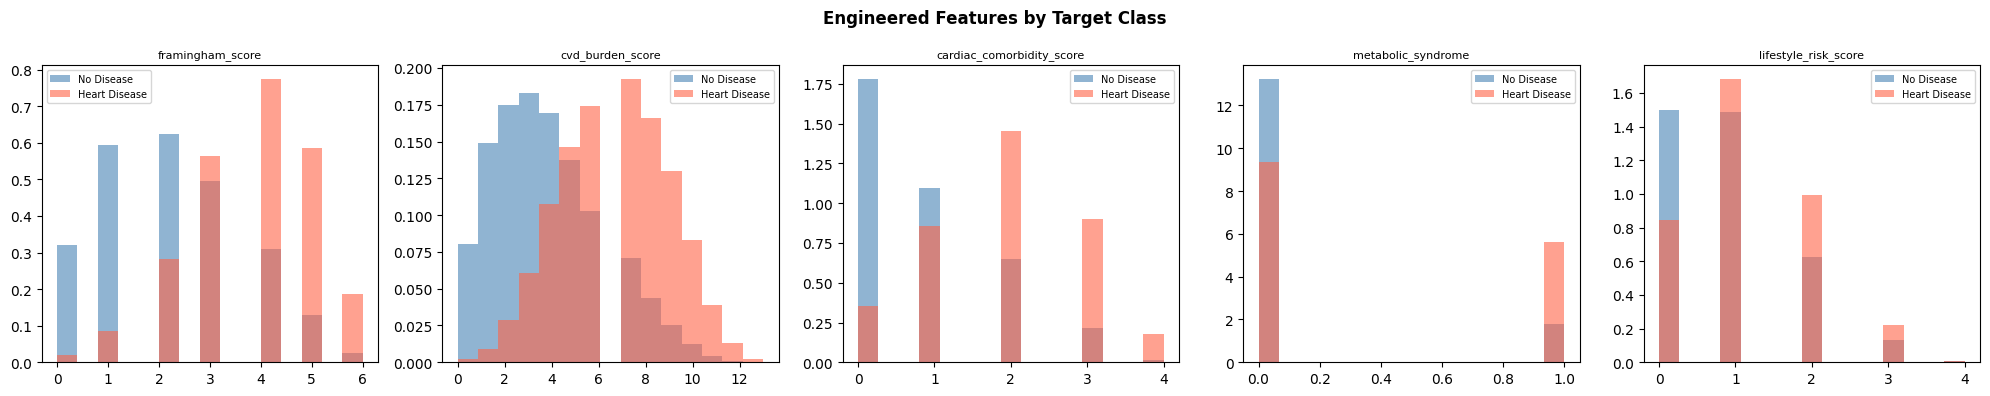

In [ ]:
composite_features = ['framingham_score','cvd_burden_score','cardiac_comorbidity_score','metabolic_syndrome','lifestyle_risk_score']
fig,axes = plt.subplots(1,len(composite_features),figsize=(20,4))
for ax,feat in zip(axes,composite_features):
    for label,color,name in [(0,'steelblue','No Disease'),(1,'tomato','Heart Disease')]:
        ax.hist(df_feat[df_feat['target']==label][feat],alpha=0.6,bins=15,color=color,label=name,density=True)
    ax.set_title(feat,fontsize=8); ax.legend(fontsize=7)
plt.suptitle('Engineered Features by Target Class',fontsize=12,fontweight='bold')
plt.tight_layout(); plt.show()


## 8. X / y Split

In [ ]:
y = df_feat['target'].astype(int)
X = df_feat.drop(columns=['target'])
POS_WEIGHT = float(y.value_counts()[0] / y.value_counts()[1])
print(f'Feature matrix : {X.shape}')
print(f'Class counts   : {y.value_counts().to_dict()}')
print(f'Imbalance ratio: {POS_WEIGHT:.2f} : 1  (used as scale_pos_weight)')
X.head()


Feature matrix : (221390, 54)
Class counts   : {0: 203322, 1: 18068}
Imbalance ratio: 11.25 : 1  (used as scale_pos_weight)


,high_bp,high_chol,chol_checked,bmi,smoker,stroke,diabetes,physical_activity,heavy_alcohol,healthcare_coverage,...,triple_metabolic,cardiac_comorbidity_score,elderly_obese,htn_no_access,age_log,age_sq,bmi_age,poor_health_flag,cvd_burden_score,age_x_framingham
0,1.0,1.0,1.0,40.68,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,2.0,0,0.0,4.174387,4096,2603.52,1,9.0,2.56
1,0.0,0.0,0.0,24.36,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0,0.0,3.931826,2500,1218.00,1,4.0,0.50
2,1.0,1.0,1.0,27.33,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,2.0,0,1.0,4.127134,3721,1667.13,1,6.0,1.83
3,1.0,0.0,1.0,27.01,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,1.0,0,0.0,4.317488,5476,1998.74,0,2.0,1.48
5,1.0,1.0,1.0,25.11,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,2.0,0,0.0,4.219508,4489,1682.37,0,6.0,3.35


## 9. StratifiedKFold + BorderlineSMOTE + F2 Threshold Optimisation

**F2 insight:** F2 = 5·P·R / (4·P + R) weights recall 4× more than precision. A fixed 0.5 threshold almost always misses the F2 optimum. We search 160 threshold candidates per fold and average the optimal values.

**BorderlineSMOTE** synthesises samples near the decision boundary — harder positives, better recall.


In [ ]:
def build_models(pos_weight=None):
    pw = pos_weight if pos_weight else POS_WEIGHT
    models = {
        'LogisticRegression': LogisticRegression(
            max_iter=2000, C=0.05, class_weight='balanced',
            solver='saga', random_state=RANDOM_STATE
        )
    }
    if HAS_XGB:
        models['XGBoost'] = xgb.XGBClassifier(
            n_estimators=500, learning_rate=0.03, max_depth=5,
            subsample=0.8, colsample_bytree=0.8,
            min_child_weight=5, gamma=0.1,
            reg_alpha=0.1, reg_lambda=1.0,
            scale_pos_weight=pw,
            eval_metric='logloss', random_state=RANDOM_STATE,
            n_jobs=-1, tree_method='hist'
        )
    if HAS_LGBM:
        models['LightGBM'] = lgb.LGBMClassifier(
            n_estimators=500, learning_rate=0.03, num_leaves=63,
            max_depth=-1, min_child_samples=20,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
    return models

print('Available models:', list(build_models().keys()))


Available models: ['LogisticRegression', 'XGBoost', 'LightGBM']


In [ ]:
def train_evaluate(X, y, n_splits=5):
    """
    StratifiedKFold CV with BorderlineSMOTE (training fold only).
    Primary metric: F2 (beta=2) with per-fold threshold optimisation.
    """
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
    models = build_models(pos_weight=POS_WEIGHT)
    all_results = []
    THRESHOLDS = np.arange(0.05, 0.85, 0.005)   # 160 candidates

    for model_name, clf in models.items():
        print(f'\n{"-"*65}')
        print(f'  Model: {model_name}')
        print(f'{"-"*65}')
        fold_roc, fold_pr, fold_f2, fold_thresh = [], [], [], []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr  = X.iloc[train_idx].copy(); X_val = X.iloc[val_idx].copy()
            y_tr  = y.iloc[train_idx].copy(); y_val = y.iloc[val_idx].copy()

            scaler   = RobustScaler()
            X_tr_sc  = scaler.fit_transform(X_tr)
            X_val_sc = scaler.transform(X_val)

            X_res, y_res = smote.fit_resample(X_tr_sc, y_tr)
            clf_fold = clone(clf)
            clf_fold.fit(X_res, y_res)

            y_prob = clf_fold.predict_proba(X_val_sc)[:, 1]

            f2_vals = np.array([
                fbeta_score(y_val, (y_prob >= t).astype(int), beta=2, zero_division=0)
                for t in THRESHOLDS
            ])
            best_t  = float(THRESHOLDS[np.argmax(f2_vals)])
            best_f2 = float(f2_vals.max())

            roc = roc_auc_score(y_val, y_prob)
            pr  = average_precision_score(y_val, y_prob)

            fold_roc.append(roc);    fold_pr.append(pr)
            fold_f2.append(best_f2); fold_thresh.append(best_t)
            print(f'  Fold {fold}  ROC={roc:.4f}  PR={pr:.4f}  '
                  f'F2={best_f2:.4f}  opt_thresh={best_t:.3f}')

        avg_thresh = float(np.mean(fold_thresh))
        row = dict(
            Model=model_name,
            roc_auc_mean=np.mean(fold_roc),  roc_auc_std=np.std(fold_roc),
            pr_auc_mean=np.mean(fold_pr),    pr_auc_std=np.std(fold_pr),
            f2_mean=np.mean(fold_f2),        f2_std=np.std(fold_f2),
            opt_threshold=avg_thresh,
        )
        all_results.append(row)
        print(f'  MEAN | ROC={row["roc_auc_mean"]:.4f}  PR={row["pr_auc_mean"]:.4f}  '
              f'F2={row["f2_mean"]:.4f}+/-{row["f2_std"]:.4f}  '
              f'opt_threshold={avg_thresh:.3f}')

    return pd.DataFrame(all_results)


results_df = train_evaluate(X, y, n_splits=N_SPLITS)


## 10. Results Summary

In [ ]:
display_cols = ['Model','f2_mean','f2_std','roc_auc_mean','pr_auc_mean','opt_threshold']
print('=== Cross-Validation Summary (sorted by F2) ===')
display(results_df[display_cols].sort_values('f2_mean', ascending=False).round(4))


In [ ]:
fig,axes = plt.subplots(1,3,figsize=(18,5))
sdf = results_df.sort_values('f2_mean', ascending=False)
for ax,(metric,title) in zip(axes,[('f2_mean','F2 (primary)'),('roc_auc_mean','ROC-AUC'),('opt_threshold','Optimal Threshold')]):
    std_col = metric.replace('mean','std') if 'mean' in metric else None
    yerr = sdf[std_col] if std_col and std_col in sdf.columns else None
    ax.bar(sdf['Model'], sdf[metric], yerr=yerr, color='steelblue', alpha=0.8, capsize=4)
    ax.set_title(title)
    ax.set_xticklabels(sdf['Model'], rotation=20, ha='right')
    for i,v in enumerate(sdf[metric]): ax.text(i,v+0.002,f'{v:.3f}',ha='center',fontsize=8)
plt.suptitle('Model Comparison — 5-Fold CV + BorderlineSMOTE + F2 Threshold',fontsize=11,fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Grid Search Hyperparameter Optimisation

Searches XGBoost and LightGBM parameter grids using **3-fold CV** to maximise F2.
Uses the same BorderlineSMOTE + per-fold threshold optimisation as the main CV loop.

| Model | Grid axes | Combos | Est. runtime |
|---|---|---|---|
| XGBoost | max_depth × learning_rate × min_child_weight × subsample | 24 × 3-fold | ~25–35 min |
| LightGBM | num_leaves × learning_rate × min_child_samples × subsample | 24 × 3-fold | ~8–12 min |

`n_estimators=300` during search for speed; best params retrained with `n_estimators=500`.

In [ ]:
XGB_PARAM_GRID = {
    'max_depth':        [4, 5, 6],
    'learning_rate':    [0.02, 0.05],
    'min_child_weight': [3, 7],
    'subsample':        [0.75, 0.90],
}  # 3x2x2x2 = 24 combinations

LGBM_PARAM_GRID = {
    'num_leaves':        [31, 63, 127],
    'learning_rate':     [0.02, 0.05],
    'min_child_samples': [20, 50],
    'subsample':         [0.75, 0.90],
}  # 3x2x2x2 = 24 combinations


def grid_search_f2(model_cls, fixed_params, param_grid, X, y, n_splits=3):
    """Manual grid search maximising mean F2 with per-fold threshold optimisation."""
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    smote = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
    THRESH = np.arange(0.05, 0.85, 0.01)

    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    best_score, best_params = -np.inf, {}
    t0 = time.time()

    for ci, combo in enumerate(combos, 1):
        params  = {**fixed_params, **dict(zip(keys, combo))}
        clf     = model_cls(**params)
        fold_f2 = []

        for tr_idx, val_idx in skf.split(X, y):
            X_tr  = X.iloc[tr_idx];  X_val = X.iloc[val_idx]
            y_tr  = y.iloc[tr_idx];  y_val = y.iloc[val_idx]
            sc       = RobustScaler()
            X_tr_sc  = sc.fit_transform(X_tr)
            X_val_sc = sc.transform(X_val)
            X_res, y_res = smote.fit_resample(X_tr_sc, y_tr)
            clf.fit(X_res, y_res)
            y_prob = clf.predict_proba(X_val_sc)[:, 1]
            f2v = [fbeta_score(y_val, (y_prob >= t).astype(int),
                               beta=2, zero_division=0) for t in THRESH]
            fold_f2.append(max(f2v))

        mean_f2 = float(np.mean(fold_f2))
        elapsed = time.time() - t0
        eta     = (elapsed / ci) * (len(combos) - ci)
        tag     = '  '.join(f'{k}={v}' for k,v in dict(zip(keys,combo)).items())
        marker  = '  <-- best' if mean_f2 > best_score else ''
        print(f'  [{ci:2d}/{len(combos)}] {tag}  '
              f'F2={mean_f2:.4f}  {elapsed/60:.1f}m elapsed  ETA {eta/60:.1f}m{marker}')

        if mean_f2 > best_score:
            best_score  = mean_f2
            best_params = dict(zip(keys, combo))

    return best_score, dict(best_params)


BEST_SEARCH_PARAMS = {}  # injected into ensemble below

if HAS_XGB:
    print('=' * 65)
    print('XGBoost Grid Search  (24 combos x 3-fold CV)')
    print('=' * 65)
    xgb_fixed = dict(
        n_estimators=300, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        scale_pos_weight=POS_WEIGHT, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1, tree_method='hist',
    )
    xgb_f2, xgb_best = grid_search_f2(xgb.XGBClassifier, xgb_fixed, XGB_PARAM_GRID, X, y)
    print(f'\nBest XGBoost F2: {xgb_f2:.4f}  params: {xgb_best}')
    BEST_SEARCH_PARAMS['XGBoost'] = {**xgb_fixed, **xgb_best, 'n_estimators': 500}

if HAS_LGBM:
    print('\n' + '=' * 65)
    print('LightGBM Grid Search  (24 combos x 3-fold CV)')
    print('=' * 65)
    lgbm_fixed = dict(
        n_estimators=300, colsample_bytree=0.8,
        is_unbalance=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    )
    lgbm_f2, lgbm_best = grid_search_f2(lgb.LGBMClassifier, lgbm_fixed, LGBM_PARAM_GRID, X, y)
    print(f'\nBest LightGBM F2: {lgbm_f2:.4f}  params: {lgbm_best}')
    BEST_SEARCH_PARAMS['LightGBM'] = {**lgbm_fixed, **lgbm_best, 'n_estimators': 500}

print('\n=== Grid Search Complete ===')
for name, params in BEST_SEARCH_PARAMS.items():
    print(f'  {name}: {params}')


## 12. Final Model — Soft-Voting Ensemble (Top-3 by F2)

Probability averaging (soft voting) across the three best models reduces variance.
Grid-searched params are injected automatically if available.
The ensemble threshold is the mean of per-model optimal thresholds from CV.


In [ ]:
top3 = results_df.sort_values('f2_mean', ascending=False).head(3)['Model'].tolist()
best_model_name = top3[0]
ensemble_threshold = float(
    results_df[results_df['Model'].isin(top3)]['opt_threshold'].mean()
)
print(f'Ensemble members (top-3 by F2): {top3}')
print(f'Ensemble opt threshold (mean of CV thresholds): {ensemble_threshold:.3f}')

# Build base models; inject grid-searched params where available
all_models = build_models(pos_weight=POS_WEIGHT)
if 'XGBoost' in BEST_SEARCH_PARAMS and HAS_XGB:
    all_models['XGBoost'] = xgb.XGBClassifier(**BEST_SEARCH_PARAMS['XGBoost'])
    print('Injected grid-searched XGBoost params.')
if 'LightGBM' in BEST_SEARCH_PARAMS and HAS_LGBM:
    all_models['LightGBM'] = lgb.LGBMClassifier(**BEST_SEARCH_PARAMS['LightGBM'])
    print('Injected grid-searched LightGBM params.')

scaler_final = RobustScaler()
smote_final  = BorderlineSMOTE(kind='borderline-1', random_state=RANDOM_STATE)
X_sc_full          = scaler_final.fit_transform(X)
X_res_full, y_res_full = smote_final.fit_resample(X_sc_full, y)

trained_models = {}
for name in top3:
    clf = clone(all_models[name])
    clf.fit(X_res_full, y_res_full)
    trained_models[name] = clf
    print(f'Trained: {name}  on {len(y_res_full):,} samples')

final_clf = trained_models[best_model_name]


In [ ]:
if hasattr(final_clf, 'feature_importances_'):
    fi = pd.Series(final_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    fig,ax = plt.subplots(figsize=(10,10))
    fi.head(30).plot(kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_title(f'Top 30 Feature Importances ({best_model_name})', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout(); plt.show()
    print('\nTop 30 features:')
    print(fi.head(30).to_string())
elif hasattr(final_clf, 'coef_'):
    coef = pd.Series(np.abs(final_clf.coef_[0]), index=X.columns).sort_values(ascending=False)
    print('Top 30 |coefficients|:')
    print(coef.head(30).to_string())


## 13. Predict test.csv & Generate Submission

In [ ]:
df_test_raw = pd.read_csv(TEST_PATH)
df_test_raw.rename(columns=COLUMN_MAP, inplace=True)
test_ids = df_test_raw['id'].values if 'id' in df_test_raw.columns else df_test_raw.index.values
if 'id' in df_test_raw.columns:
    df_test_raw = df_test_raw.drop(columns=['id'])

df_test_enc   = encode_data(df_test_raw, is_train=False)
df_test_clean = handle_missing(df_test_enc, fit=False)
df_test_feat  = engineer_features(df_test_clean)

for col in X.columns:
    if col not in df_test_feat.columns:
        df_test_feat[col] = 0
        print(f'  [warn] Missing in test, filled 0: {col}')

X_test    = df_test_feat[X.columns]
X_test_sc = scaler_final.transform(X_test)
print(f'Test feature matrix: {X_test_sc.shape}')


In [ ]:
# Soft-voting ensemble: average probabilities from top-3 models
test_probas    = np.column_stack([trained_models[n].predict_proba(X_test_sc)[:,1] for n in top3])
ensemble_proba = test_probas.mean(axis=1)

THRESHOLD = ensemble_threshold
test_pred  = (ensemble_proba >= THRESHOLD).astype(int)
print(f'Ensemble threshold (F2-optimal): {THRESHOLD:.3f}')
print(f'Predicted positives: {test_pred.sum()} / {len(test_pred)} ({test_pred.mean()*100:.2f}%)')

plt.figure(figsize=(8,3))
plt.hist(ensemble_proba, bins=50, color='steelblue', edgecolor='white')
plt.axvline(THRESHOLD, color='tomato', linestyle='--', label=f'threshold={THRESHOLD:.3f}')
plt.title('Ensemble Predicted Probabilities (Test Set)')
plt.xlabel('P(Heart Disease)'); plt.legend(); plt.tight_layout(); plt.show()


In [ ]:
SUBMISSION_PATH = 'heart_disease_submission_esum.csv'
SAMPLE_SUB_PATH = ('/kaggle/input/competitions/'
                   'super-ai-engineer-ss-6-heart-disease-prediction/sample_submission.csv')

try:
    submission = pd.read_csv(SAMPLE_SUB_PATH)
    submission = submission.drop(columns=['History of HeartDisease or Attack'], errors='ignore')
except FileNotFoundError:
    submission = pd.DataFrame({'ID': test_ids})

submission['History of HeartDisease or Attack'] = np.where(test_pred == 1, 'Yes', 'No')
submission.to_csv(SUBMISSION_PATH, index=False)
print(f'Saved: {SUBMISSION_PATH}')
print(f'Yes: {(submission["History of HeartDisease or Attack"]=="Yes").sum()}')
print(f'No:  {(submission["History of HeartDisease or Attack"]=="No").sum()}')
submission.head(10)
